In [9]:
import wandb
from itertools import islice

api = wandb.Api()

# List all runs in your project

runs = api.runs(
    "weissma6-zhaw-school-of-engineering/UR10_pick_ppo",
    order="-created_at"   # newest first
)

print("10 newest runs:")
newest_10 = list(islice(runs, 10))
for run in newest_10:
    print(f"  ID: {run.id}  |  Name: {run.name}  |  State: {run.state}")

10 newest runs:
  ID: DomainR_MFR_lr0.0006_KPKV400030_20260206_194816_9462  |  Name: DomainR_MFR_lr0.0006_KPKV400030_20260206_194816_9462  |  State: running
  ID: DomainR_off_lr0.0006_KPKV400030_20260206_194816_3438  |  Name: DomainR_off_lr0.0006_KPKV400030_20260206_194816_3438  |  State: running
  ID: DomainR_MFR_lr0.0010_KPKV400030_20260206_194814_3655  |  Name: DomainR_MFR_lr0.0010_KPKV400030_20260206_194814_3655  |  State: running
  ID: DomainR_MFR_lr0.0008_KPKV400030_20260206_194813_1277  |  Name: DomainR_MFR_lr0.0008_KPKV400030_20260206_194813_1277  |  State: running
  ID: DomainR_MFR_lr0.0012_KPKV400030_20260206_194705_805  |  Name: DomainR_MFR_lr0.0012_KPKV400030_20260206_194705_805  |  State: running
  ID: DomainR_MFR_lr0.0006_KPKV400030_20260206_192232_7558  |  Name: DomainR_MFR_lr0.0006_KPKV400030_20260206_192232_7558  |  State: crashed
  ID: DomainR_off_forcerange10_20260206_173852_9143  |  Name: DomainR_off_forcerange10_20260206_173852_9143  |  State: finished
  ID: Domain

# Create Graphs
pick some rollouts on W&B and create graphs

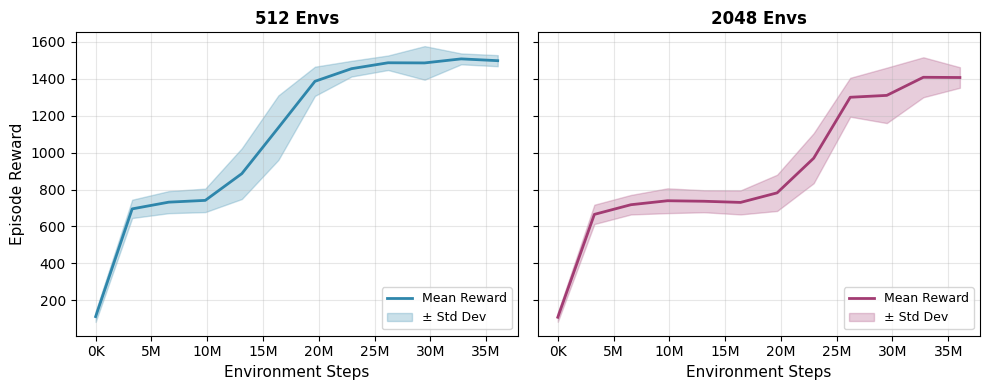

In [10]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Fetch data from W&B ---
api = wandb.Api()
user = "weissma6-zhaw-school-of-engineering"
project = "UR10_pick_ppo"
runs = {
    "512 Envs": "lift_512Envs_20260124_164012_5264",
    "2048 Envs": "lift_2048Envs_20260124_163951_172",
}

data = {}
for label, run_id in runs.items():
    run = api.run(f"{user}/{project}/{run_id}")
    history = run.history(keys=["eval/episode_reward", "eval/episode_reward_std"])
    history = history.dropna()  # Remove NaN rows
    data[label] = history

# --- Plot ---
fig, axes = plt.subplots(1, len(runs), figsize=(5 * len(runs), 4), sharey=True)

# Color palette (adjust as needed)
colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"]

for ax, (label, df), color in zip(axes, data.items(), colors):
    steps = df["_step"] if "_step" in df.columns else df.index
    mean = df["eval/episode_reward"]
    std = df["eval/episode_reward_std"]
    
    # Plot mean line
    ax.plot(steps, mean, color=color, linewidth=2, label="Mean Reward")
    
    # Plot std band
    ax.fill_between(
        steps,
        mean - std,
        mean + std,
        color=color,
        alpha=0.25,
        label="± Std Dev"
    )
    
    ax.set_xlabel("Environment Steps", fontsize=11)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)

    # Format x-axis with millions
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
    )

axes[0].set_ylabel("Episode Reward", fontsize=11)

plt.tight_layout()
# plt.savefig("reward_comparison.pdf", bbox_inches="tight", dpi=300)
# plt.savefig("reward_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

In [11]:
import wandb

api = wandb.Api()

# List all runs in your project
runs = api.runs("weissma6-zhaw-school-of-engineering/panda_pick_ppo")

print("Available runs:")
for run in runs:
    print(f"  ID: {run.id}  |  Name: {run.name}  |  State: {run.state}")

Available runs:
  ID: kfuvh2dk  |  Name: ppo_lr_low  |  State: crashed
  ID: 6d5wwz5m  |  Name: ppo_base  |  State: crashed
  ID: lqrqc57g  |  Name: ppo_lr_high  |  State: crashed
  ID: uklf1fv7  |  Name: ppo_base_seed1  |  State: crashed
  ID: aqu8w3zp  |  Name: ppo_entropy_high  |  State: crashed
  ID: t116xy53  |  Name: lr_large  |  State: finished
  ID: u6w6qohc  |  Name: lr_small  |  State: finished
  ID: 7lhpk8r4  |  Name: default  |  State: finished
  ID: kt25cruq  |  Name: lr_small  |  State: finished
  ID: umm9hky6  |  Name: default_seed6  |  State: finished
  ID: xd3m93vt  |  Name: lr_large  |  State: finished
  ID: dt87nxa6  |  Name: lr_small  |  State: finished
  ID: 2fmtgbv4  |  Name: lr_large  |  State: finished
  ID: f2a0z34b  |  Name: default_seed6  |  State: finished
  ID: uj2trobp  |  Name: default  |  State: finished
  ID: 9j17y4ca  |  Name: lr_small  |  State: finished
  ID: o5j9h47f  |  Name: lr_large  |  State: finished
  ID: 5z23v55u  |  Name: default  |  State: 

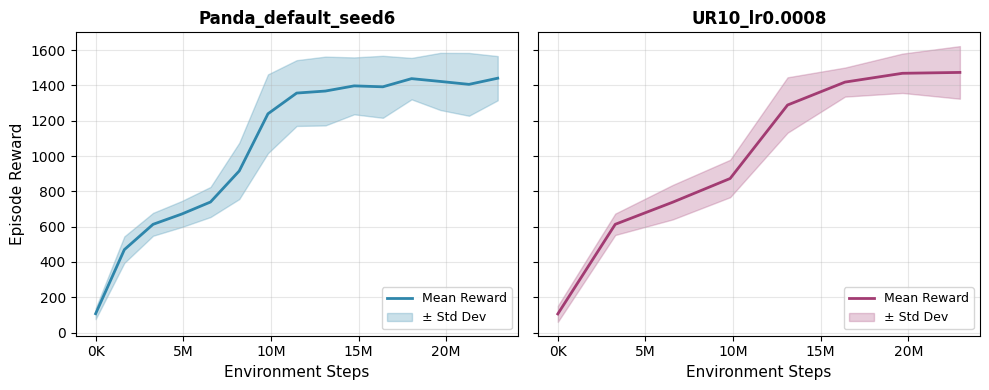

In [12]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Fetch data from W&B ---
api = wandb.Api()
user = "weissma6-zhaw-school-of-engineering"

runs = {
    "Panda_default_seed6": ("panda_pick_ppo", "2hcb0tlw"),
    "UR10_lr0.0008":       ("UR10_pick_ppo",  "DomainR_MFR_lr0.0006_KPKV400030_20260206_194816_9462"),
}

data = {}
for label, (project, run_id) in runs.items():
    run = api.run(f"{user}/{project}/{run_id}")
    history = run.history(keys=["eval/episode_reward", "eval/episode_reward_std"])
    history = history.dropna()
    data[label] = history

# --- Plot ---
fig, axes = plt.subplots(1, len(runs), figsize=(5 * len(runs), 4), sharey=True)

colors = ["#2E86AB", "#A23B72", "#F18F01"]

for ax, (label, df), color in zip(axes, data.items(), colors):
    steps = df["_step"] if "_step" in df.columns else df.index
    mean = df["eval/episode_reward"]
    std = df["eval/episode_reward_std"]

    ax.plot(steps, mean, color=color, linewidth=2, label="Mean Reward")
    ax.fill_between(steps, mean - std, mean + std,
                     color=color, alpha=0.25, label="± Std Dev")

    ax.set_xlabel("Environment Steps", fontsize=11)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
    )

axes[0].set_ylabel("Episode Reward", fontsize=11)

plt.tight_layout()
# plt.savefig("reward_comparison_ur10_panda.pdf", bbox_inches="tight", dpi=300)
# plt.savefig("reward_comparison_ur10_panda.png", bbox_inches="tight", dpi=300)
plt.show()

# Getting Training Data
Get as much training data as possible to show in the Report